In [4]:
import numpy as np
import pandas as pd
import glob
from helper import get_data_splits, id_key, get_model
from define_model import create_MultiTaskTouchPoseNet
from my_helpers import *
from itertools import zip_longest
import pprint as p

2023-07-17 11:38:51.582215: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-17 11:38:52.238061: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
# Below identifiers correspond to evaluation protocol 1, 2 and 3 respectively
# identifiers - "TouchPose_crossSession", "TouchPose_crossSubjects", "TouchPose_crossGestures"
identifier = "TouchPose_crossGestures"
data_path = "../data/eth_data/"
model_path = "../models/"
new_data = "../data/27Arish"
our_data = "../data/gen_data"

In [7]:
files = glob.glob(data_path+'*.pkl')
df = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)

In [8]:
control = id_key[identifier]
df_group = df.groupby([control])[["cap_img","depth_img"]]
g_id = list(df_group.groups.keys())

In [9]:
depth_err = []
for i in range(len(g_id)):
    test_set = [g_id[i]]
    X_test_cap, Y_test_depth= get_data_splits(df_group,test_set)
    model = get_model(identifier, model_path, test_set)
    Y_out_depth = model.predict(X_test_cap, batch_size=128)
    depth_error = np.mean(abs(Y_test_depth - Y_out_depth[:,:,:,0])) * 255
    depth_err.append(depth_error)
    print("Accuracy", g_id[i],depth_error)
    break


2023-07-17 11:38:55.878256: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-07-17 11:38:55.899728: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-07-17 11:38:55.900055: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

2023-07-17 11:38:57.381142: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2023-07-17 11:38:57.758478: E tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:114] *** WARNING *** You are using ptxas 9.1.108, which is older than 11.1. ptxas before 11.1 is known to miscompile XLA code, leading to incorrect results or invalid-address errors.



42/42 [==============================] - 6s 66ms/step
Accuracy 65.0 30.418464748823904


In [10]:
model.layers

In [11]:
multi_task_model = create_MultiTaskTouchPoseNet(41, 72, 1)

## Now we will assign weights to multi task model from depth model

In [12]:
match = []
for depth_layer, multi_layer, matching in zip_longest(model.layers,multi_task_model.layers,range(len(multi_task_model.layers)),fillvalue='0'):
        if(depth_layer!='0'):
            match.append((depth_layer.name, multi_layer.name, (matching,matching)))
        else : 
            match.append((depth_layer, multi_layer.name,(matching,matching)))
match

[('input_25', 'input_1', (0, 0)),
 ('conv2d_336', 'conv2d', (1, 1)),
 ('conv2d_337', 'conv2d_1', (2, 2)),
 ('max_pooling2d_72', 'max_pooling2d', (3, 3)),
 ('conv2d_338', 'conv2d_2', (4, 4)),
 ('conv2d_339', 'conv2d_3', (5, 5)),
 ('max_pooling2d_73', 'max_pooling2d_1', (6, 6)),
 ('conv2d_340', 'conv2d_4', (7, 7)),
 ('conv2d_341', 'conv2d_5', (8, 8)),
 ('max_pooling2d_74', 'max_pooling2d_2', (9, 9)),
 ('conv2d_342', 'conv2d_6', (10, 10)),
 ('conv2d_343', 'conv2d_7', (11, 11)),
 ('up_sampling2d_72', 'up_sampling2d', (12, 12)),
 ('concatenate_72', 'concatenate', (13, 13)),
 ('conv2d_344', 'conv2d_8', (14, 14)),
 ('conv2d_345', 'conv2d_9', (15, 15)),
 ('up_sampling2d_73', 'up_sampling2d_1', (16, 16)),
 ('concatenate_73', 'concatenate_1', (17, 17)),
 ('conv2d_346', 'conv2d_10', (18, 18)),
 ('conv2d_347', 'flatten', (19, 19)),
 ('up_sampling2d_74', 'conv2d_11', (20, 20)),
 ('tf.compat.v1.pad_24', 'dense', (21, 21)),
 ('concatenate_74', 'up_sampling2d_2', (22, 22)),
 ('conv2d_348', 'activation

In [13]:
match = [ (''.join([ xi for xi in x[0] if not (xi.isdigit() or xi== '_')]),''.join([ xi for xi in x[1] if not (xi.isdigit() or xi== '_')]), x[2]) for x in match]
bad_match = [x for x in match if x[0]!=x[1]]
bad_match

[('convd', 'flatten', (19, 19)),
 ('upsamplingd', 'convd', (20, 20)),
 ('tf.compat.v.pad', 'dense', (21, 21)),
 ('concatenate', 'upsamplingd', (22, 22)),
 ('convd', 'activation', (23, 23)),
 ('convd', 'tf.compat.v.pad', (24, 24)),
 ('regressiondepth', 'batchnormalization', (25, 25)),
 ('', 'concatenate', (26, 26)),
 ('', 'dropout', (27, 27)),
 ('', 'convd', (28, 28)),
 ('', 'dense', (29, 29)),
 ('', 'convd', (30, 30)),
 ('', 'regression', (31, 31)),
 ('', 'visibility', (32, 32)),
 ('', 'regressiondepth', (33, 33))]

In [14]:
bad_match_sec = bad_match.copy()

for i in range(len(bad_match)):
    for j in range(len(bad_match_sec)):
        if bad_match[i][0]==bad_match_sec[j][1]:
            new_match = list(bad_match[i])
            new_match[1] = bad_match_sec[j][1]
            new_match[2] = (bad_match[i][2][0],bad_match_sec[j][2][1])
            bad_match[i] = tuple(new_match)
            bad_match_sec.remove(bad_match_sec[j])
            break

bad_match

[('convd', 'convd', (19, 20)),
 ('upsamplingd', 'upsamplingd', (20, 22)),
 ('tf.compat.v.pad', 'tf.compat.v.pad', (21, 24)),
 ('concatenate', 'concatenate', (22, 26)),
 ('convd', 'convd', (23, 28)),
 ('convd', 'convd', (24, 30)),
 ('regressiondepth', 'regressiondepth', (25, 33)),
 ('', 'concatenate', (26, 26)),
 ('', 'dropout', (27, 27)),
 ('', 'convd', (28, 28)),
 ('', 'dense', (29, 29)),
 ('', 'convd', (30, 30)),
 ('', 'regression', (31, 31)),
 ('', 'visibility', (32, 32)),
 ('', 'regressiondepth', (33, 33))]

In [15]:
good_match = [x for x in match if x[0]==x[1]]
match = [x for x in good_match + bad_match if x[0]==x[1]]
match

[('input', 'input', (0, 0)),
 ('convd', 'convd', (1, 1)),
 ('convd', 'convd', (2, 2)),
 ('maxpoolingd', 'maxpoolingd', (3, 3)),
 ('convd', 'convd', (4, 4)),
 ('convd', 'convd', (5, 5)),
 ('maxpoolingd', 'maxpoolingd', (6, 6)),
 ('convd', 'convd', (7, 7)),
 ('convd', 'convd', (8, 8)),
 ('maxpoolingd', 'maxpoolingd', (9, 9)),
 ('convd', 'convd', (10, 10)),
 ('convd', 'convd', (11, 11)),
 ('upsamplingd', 'upsamplingd', (12, 12)),
 ('concatenate', 'concatenate', (13, 13)),
 ('convd', 'convd', (14, 14)),
 ('convd', 'convd', (15, 15)),
 ('upsamplingd', 'upsamplingd', (16, 16)),
 ('concatenate', 'concatenate', (17, 17)),
 ('convd', 'convd', (18, 18)),
 ('convd', 'convd', (19, 20)),
 ('upsamplingd', 'upsamplingd', (20, 22)),
 ('tf.compat.v.pad', 'tf.compat.v.pad', (21, 24)),
 ('concatenate', 'concatenate', (22, 26)),
 ('convd', 'convd', (23, 28)),
 ('convd', 'convd', (24, 30)),
 ('regressiondepth', 'regressiondepth', (25, 33))]

For now keep bottleneck, check later for both


In [16]:
for i in range(len(model.layers)):
    d = match[i][2][0]
    m = match[i][2][1]
    multi_task_model.layers[m].set_weights(model.layers[d].get_weights())

## Model is partially loaded

In [17]:
p.pprint(model.input)
print('multi model')
p.pprint(multi_task_model.input)

<KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'input_25')>
multi model
<KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'input_1')>


In [18]:
p.pprint(model.output)
print('multi model')
p.pprint(multi_task_model.output)


<KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'regression_depth')>
multi model
[<KerasTensor: shape=(None, 63) dtype=float32 (created by layer 'regression')>,
 <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'visibility')>,
 <KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'regression_depth')>]


In [19]:
cap_img = read_cap_img(new_data+"/Arish_1_UP_100_rawdata.csv")
skeleton = read_skeleton(new_data+"/userarish_2023-04-03_10-10-07_11956_handleap.csv")

In [20]:
skeleton.Timestamp = skeleton.Timestamp.astype('int64')*1000
cap_img = cap_img.rename(columns={'TimeStamps': 'Timestamp'})
cap_img.head()

,Timestamp,MergeTimeStamps,ScanSizeX,ScanSizeY,img
0,1680508053473,1680508053470,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1680508053489,1680508053485,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,1680508053506,1680508053505,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,1680508053519,1680508053515,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,1680508053532,1680508053530,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [21]:
both=pd.merge(skeleton, cap_img[['img','Timestamp']], on='Timestamp', how='inner') 
print(len(both))
both.columns

347


Index(['Timestamp', 'wrist_x', 'wrist_y', 'wrist_z', 'Thumb_0_x', 'Thumb_0_y',
       'Thumb_0_z', 'Thumb_1_x', 'Thumb_1_y', 'Thumb_1_z', 'Thumb_2_x',
       'Thumb_2_y', 'Thumb_2_z', 'Thumb_3_x', 'Thumb_3_y', 'Thumb_3_z',
       'Index_0_x', 'Index_0_y', 'Index_0_z', 'Index_1_x', 'Index_1_y',
       'Index_1_z', 'Index_2_x', 'Index_2_y', 'Index_2_z', 'Index_3_x',
       'Index_3_y', 'Index_3_z', 'Middle_0_x', 'Middle_0_y', 'Middle_0_z',
       'Middle_1_x', 'Middle_1_y', 'Middle_1_z', 'Middle_2_x', 'Middle_2_y',
       'Middle_2_z', 'Middle_3_x', 'Middle_3_y', 'Middle_3_z', 'Ring_0_x',
       'Ring_0_y', 'Ring_0_z', 'Ring_1_x', 'Ring_1_y', 'Ring_1_z', 'Ring_2_x',
       'Ring_2_y', 'Ring_2_z', 'Ring_3_x', 'Ring_3_y', 'Ring_3_z', 'Pinky_0_x',
       'Pinky_0_y', 'Pinky_0_z', 'Pinky_1_x', 'Pinky_1_y', 'Pinky_1_z',
       'Pinky_2_x', 'Pinky_2_y', 'Pinky_2_z', 'Pinky_3_x', 'Pinky_3_y',
       'Pinky_3_z', 'img'],
      dtype='object')

In [22]:
input = prepare_input(both)
input.shape

(347, 41, 72)

In [23]:
ys=multi_task_model.predict(input, batch_size=128)

3/3 [==============================] - 1s 636ms/step


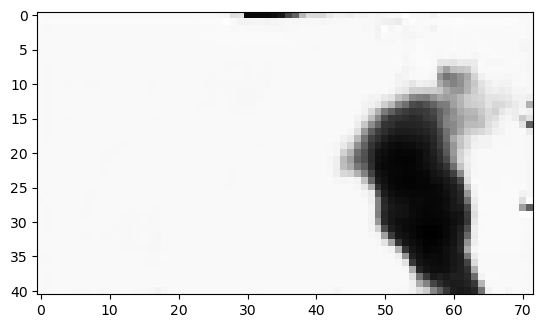

In [24]:
plt.imshow(ys[2][0], cmap='gray')

Same Direcly predict on some test data

In [27]:
data = pd.read_pickle(our_data+'/Arish_1_UP_100_.pkl')

In [28]:
input=prepare_input(data)
input.shape

(1255, 41, 72)

In [29]:
ys = multi_task_model.predict(input, batch_size=128)

10/10 [==============================] - 2s 204ms/step


In [30]:
real_hand=data.skeleton.iloc[0]
real_hand

array([[-257.18319702,  295.58691406,   92.44268799],
       [-233.98252869,  279.4871521 ,   76.22212219],
       [-233.98252869,  279.4871521 ,   76.22212219],
       [-215.67103577,  281.85290527,   58.94637299],
       [-201.91842651,  289.1739502 ,   43.19470596],
       [-251.76046753,  278.81640625,   77.20132446],
       [-233.01950073,  274.95257568,   32.20753479],
       [-210.90457153,  284.40463257,   19.16806793],
       [-202.34353638,  292.8862915 ,   29.97721481],
       [-255.81411743,  288.54498291,   73.76652527],
       [-240.31716919,  290.74057007,   30.12089539],
       [-209.07945251,  303.0557251 ,   24.49584579],
       [-206.06414795,  304.32794189,   44.34212112],
       [-255.77580261,  296.12145996,   70.14402008],
       [-244.29472351,  303.88879395,   30.88960075],
       [-215.47265625,  314.22073364,   23.8146553 ],
       [-210.47537231,  312.96395874,   41.31074142],
       [-255.24449158,  304.73422241,   71.85959625],
       [-248.27072144,  316.

In [31]:
pred_hand=ys[0][0].reshape(21,3)
pred_hand

array([[-1.7051834e+01, -1.1627375e+01, -1.3670597e+01],
       [-1.2348354e+01,  1.9101677e+00,  7.7269478e+00],
       [-7.8301285e+01, -2.1955149e+01, -3.1082409e+01],
       [-4.6707527e+01, -4.6366010e+00, -5.9700642e+00],
       [-2.8541567e+00, -3.5166492e+01,  1.9845400e+01],
       [ 3.0465603e+01, -3.7606133e+01,  3.4362186e+01],
       [-4.1403427e+01, -4.3547096e+01,  3.5205269e+00],
       [ 1.0336520e+01,  5.0162571e+01,  1.2201668e+01],
       [ 1.5522339e+01, -4.9459496e+00, -1.4009972e+00],
       [ 1.0286090e+01, -2.8933403e+01,  6.7379951e-02],
       [-4.4337502e+00, -8.9683418e+00, -5.4045967e+01],
       [ 3.9781521e+01, -6.2988071e+00,  7.6076031e+00],
       [-2.2639771e+01, -1.7045662e+01, -1.9584620e+01],
       [ 1.4496709e+01, -1.5698606e+01, -6.3465443e+00],
       [-7.1994972e-01, -1.0708923e+01,  2.0430887e+01],
       [-4.0618305e+00,  3.8670380e+01, -1.3067570e+01],
       [ 1.4591782e+01,  3.5926728e+00,  3.8724293e+01],
       [-3.2840042e+01,  6.3931

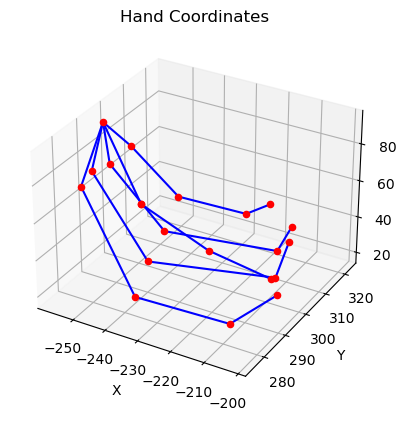

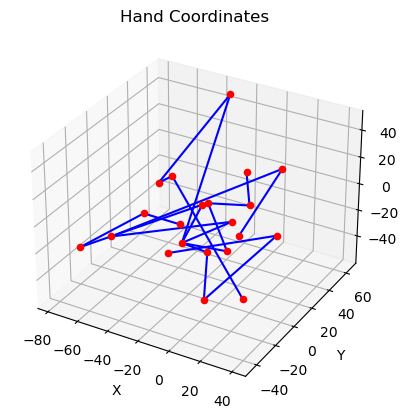

In [32]:
plot_hand(real_hand)
plot_hand(pred_hand)

Train the model

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Assuming you have your dataset stored in variables: X_img, X_skeleton, Y_skeleton

# Data preprocessing
X_img = np.array(...)  # Capacitive image data
X_skeleton = np.array(...)  # Skeleton data
Y_skeleton = np.array(...)  # Target skeleton data

# Normalize input data
X_img = X_img / 255.0

# Reshape input data
X_img = X_img.reshape(-1, 41, 72, 1)

# Split dataset into training and validation sets
X_img_train, X_img_val, X_skeleton_train, X_skeleton_val, Y_skeleton_train, Y_skeleton_val = train_test_split(
    X_img, X_skeleton, Y_skeleton, test_size=0.2, random_state=42)

# Create and compile the model
model = create_MultiTaskTouchPoseNet(41, 72, 1)
model.compile(
    optimizer='adam',
    loss={'regression': 'mean_squared_error', 'visibility': 'binary_crossentropy', 'regression_depth': 'mean_squared_error'},
    metrics={'regression': 'mae', 'visibility': 'accuracy', 'regression_depth': 'mae'}
)

# Train the model
model.fit(
    X_img_train,
    {'regression': X_skeleton_train, 'visibility': X_skeleton_train, 'regression_depth': Y_skeleton_train},
    validation_data=(
        X_img_val,
        {'regression': X_skeleton_val, 'visibility': X_skeleton_val, 'regression_depth': Y_skeleton_val}
    ),
    batch_size=32,
    epochs=100
)
